# Wilcoxon Signed-Rank Tests for Anomaly Detection Benchmark

This notebook runs paired Wilcoxon signed-rank tests on the benchmark results to evaluate:
1. **Augmentation Gains** — Does augmented training improve AUROC over clean training under degradation?
2. **Overall Rescue Deltas** — Do rescue methods recover AUROC compared to degraded baselines?
3. **Per-Rescue-Method Breakdown** — Which specific rescue methods help or hurt, with statistical significance?

## Setup & Dependencies

In [1]:
!pip install -q pandas scipy matplotlib seaborn statsmodels



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Match plotting style from generate_figures.py
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 150
})

os.makedirs('results/analysis', exist_ok=True)

## Load Dataset

Auto-detects your environment:
- **Google Colab**: Prompts you to upload `benchmark_full_4way.csv`
- **Kaggle**: Looks for the file in `/kaggle/input/`
- **Local**: Looks in the current working directory

In [3]:
CSV_FILENAME = 'benchmark_master_combined.csv'

def load_csv():
    """Auto-detect environment and load the benchmark CSV."""
    # 1. Local data directory
    local_path = os.path.join('..', 'data', CSV_FILENAME)
    if os.path.exists(local_path):
        print(f'Found {CSV_FILENAME} in ../data/ directory.')
        return pd.read_csv(local_path)
        print(f'Found {CSV_FILENAME} in current directory.')
        return pd.read_csv(CSV_FILENAME)

    # 2. Kaggle
    kaggle_base = '/kaggle/input'
    if os.path.isdir(kaggle_base):
        for root, dirs, files in os.walk(kaggle_base):
            if CSV_FILENAME in files:
                path = os.path.join(root, CSV_FILENAME)
                print(f'Found {CSV_FILENAME} at {path}')
                return pd.read_csv(path)
        print(f'CSV not found under {kaggle_base}. '
              'Make sure you have added the dataset to your Kaggle notebook.')

    # 3. Google Colab
    try:
        from google.colab import files as colab_files
        print(f"Please upload '{CSV_FILENAME}':")
        uploaded = colab_files.upload()
        if CSV_FILENAME in uploaded:
            return pd.read_csv(CSV_FILENAME)
        else:
            raise FileNotFoundError(
                f"Expected '{CSV_FILENAME}' but received: {list(uploaded.keys())}")
    except ImportError:
        pass

    raise FileNotFoundError(
        f"Could not find '{CSV_FILENAME}'. "
        'Place it in the current directory, upload it (Colab), '
        'or add it as a Kaggle dataset.')

# --- Call at top level (NOT inside load_csv) ---
df = load_csv()
print(f'Loaded successfully. Shape: {df.shape}')
df.head()

Found benchmark_master_combined.csv in current directory.
Loaded successfully. Shape: (9384, 10)


,model,dataset,category,seed,phase,ctype,severity,rescue,image_AUROC,training
0,PaDiM,MVTec-AD,bottle,42,baseline,clean,none,none,1.0,clean
1,PaDiM,MVTec-AD,bottle,42,degradation,low_light,mild,none,0.5,clean
2,PaDiM,MVTec-AD,bottle,42,degradation,low_light,moderate,none,0.5,clean
3,PaDiM,MVTec-AD,bottle,42,degradation,low_light,severe,none,0.5,clean
4,PaDiM,MVTec-AD,bottle,42,rescue,low_light,severe,CLAHE,0.5,clean


---
## Test 1 — Augmentation Gains

Compares **clean-trained** vs **augmented-trained** models under degradation (no rescue).  
Paired by `(model, category, seed, ctype, severity)`.  
One-sided test: H₁ — augmented training yields higher AUROC.

In [4]:
# Filter to degradation phase with no rescue
deg_df = df[(df['phase'] == 'degradation') & (df['rescue'] == 'none')]

clean_deg = deg_df[deg_df['training'] == 'clean']
aug_deg   = deg_df[deg_df['training'] == 'augmented']

merge_cols = ['dataset', 'model', 'category', 'seed', 'ctype', 'severity']
aug_gains_df = pd.merge(
    clean_deg[merge_cols + ['image_AUROC']],
    aug_deg[merge_cols + ['image_AUROC']],
    on=merge_cols,
    suffixes=('_clean_train', '_aug_train')
)

print('=' * 60)
print('1. Wilcoxon Signed-Rank Test: Augmentation Gains')
print('=' * 60)

test1_results = []

for (dataset, model), group in aug_gains_df.groupby(['dataset', 'model']):
    x = group['image_AUROC_clean_train']
    y = group['image_AUROC_aug_train']

    # One-sided: H1: clean < augmented
    stat, pval = wilcoxon(x, y, alternative='less')
    mean_diff = (y - x).mean()

    label = f"{dataset} - {model}"
    test1_results.append({
        'Condition': label, 'Dataset': dataset, 'Model': model, 'N': len(group),
        'Mean Clean': x.mean(), 'Mean Aug': y.mean(),
        'Mean Gain': mean_diff, 'W': stat, 'p-value': pval,
    })

    print(f'Condition: {label} (N = {len(group)})')
    print(f'  Mean Clean-Train AUROC: {x.mean():.4f}')
    print(f'  Mean Aug-Train AUROC:   {y.mean():.4f}')
    print(f'  Mean Gain:              {mean_diff:+.4f}')
    print(f'  W-Statistic:            {stat}')
    print(f'  p-value:                {pval:.2e}')
    sig = 'Yes' if pval < 0.05 else 'No'
    print(f'  Significant (a=0.05)?   {sig}')
    print('-' * 50)

test1_df = pd.DataFrame(test1_results)

1. Wilcoxon Signed-Rank Test: Augmentation Gains
Condition: MVTec-AD - PaDiM (N = 675)
  Mean Clean-Train AUROC: 0.6390
  Mean Aug-Train AUROC:   0.7400
  Mean Gain:              +0.1009
  W-Statistic:            20872.5
  p-value:                5.32e-75
  Significant (a=0.05)?   Yes
--------------------------------------------------
Condition: MVTec-AD - PatchCore (N = 675)
  Mean Clean-Train AUROC: 0.7356
  Mean Aug-Train AUROC:   0.8588
  Mean Gain:              +0.1232
  W-Statistic:            21889.5
  p-value:                3.25e-69
  Significant (a=0.05)?   Yes
--------------------------------------------------
Condition: VisA - PaDiM (N = 180)
  Mean Clean-Train AUROC: 0.5571
  Mean Aug-Train AUROC:   0.6959
  Mean Gain:              +0.1388
  W-Statistic:            581.0
  p-value:                1.63e-27
  Significant (a=0.05)?   Yes
--------------------------------------------------
Condition: VisA - PatchCore (N = 180)
  Mean Clean-Train AUROC: 0.6466
  Mean Aug-Train A

### Figure 7 — Augmentation Gains with Significance

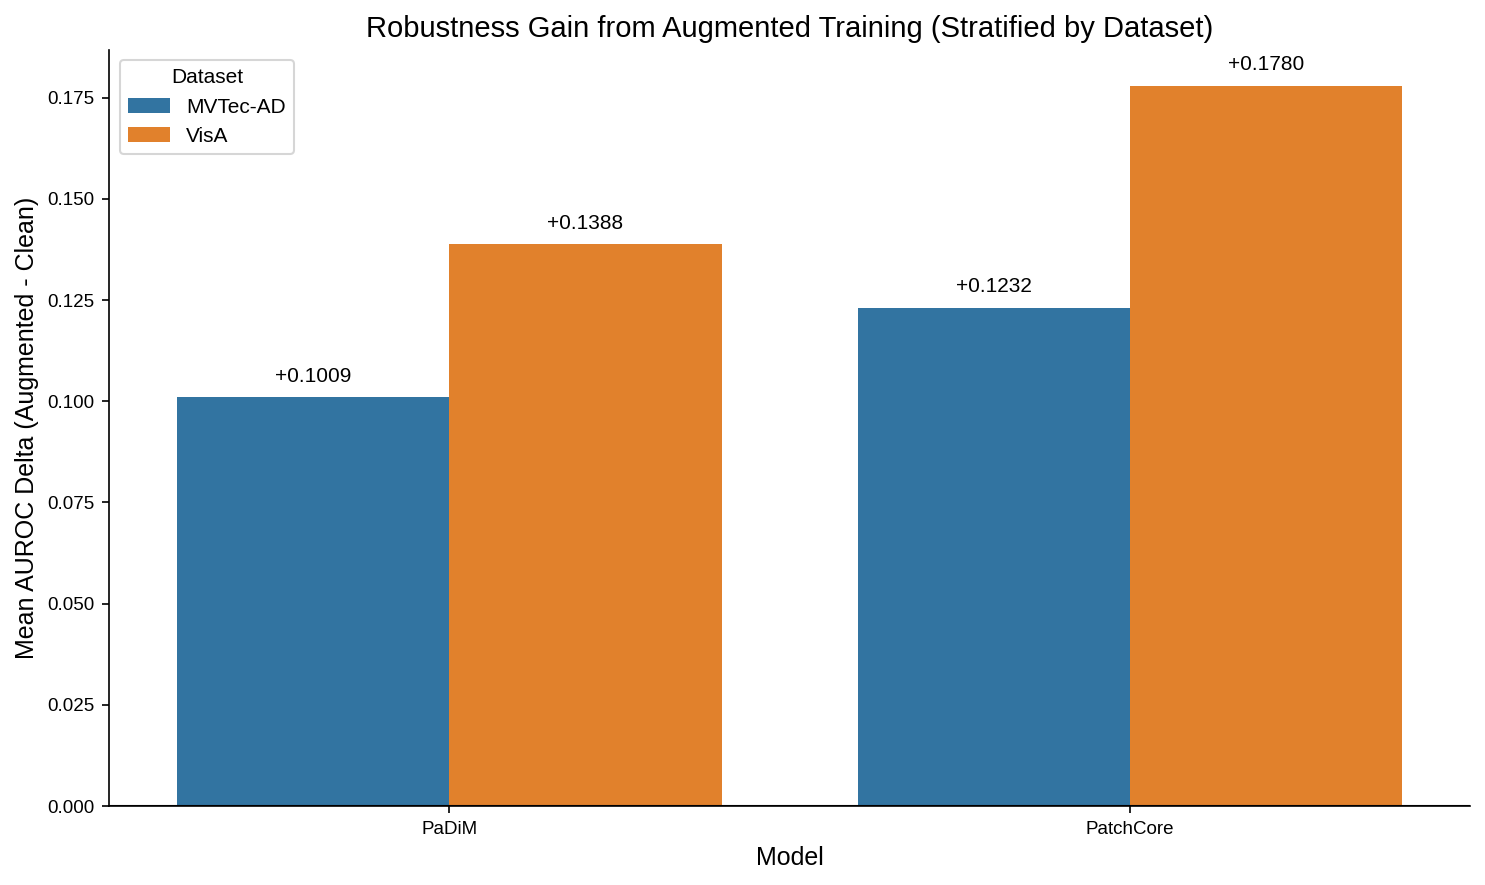

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
import seaborn as sns
sns.barplot(data=test1_df, x='Model', y='Mean Gain', hue='Dataset', palette=['#1f77b4', '#ff7f0e'], ax=ax)
ax.set_title('Robustness Gain from Augmented Training (Stratified by Dataset)', fontsize=14)
ax.set_ylabel('Mean AUROC Delta (Augmented - Clean)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.axhline(0, color='black', linewidth=1)
for p in ax.patches:
    w = p.get_width()
    if w == 0:
        continue
    h = p.get_height()
    if pd.isna(h):
        continue
    ax.annotate(f"{h:+.4f}", (p.get_x() + w / 2., h),
                ha='center', va='center', xytext=(0, 10 if h > 0 else -10), textcoords='offset points')
sns.despine()
plt.tight_layout()
fig.savefig('07_wilcoxon_augmentation_gains.png', bbox_inches='tight')
plt.show()

---
## Test 2 — Overall Rescue Deltas (Rescued vs. Degraded)

Compares **rescued AUROC** vs **degraded AUROC**.  
Paired by `(model, training, category, seed, ctype, severity)`.  
Two-sided test for any difference + one-sided test for rescue helping (degraded < rescued).

In [6]:
rescue_phase_df = df[df['phase'] == 'rescue']
rescue_pairs = pd.merge(
    rescue_phase_df,
    deg_df,
    on=['dataset', 'model', 'training', 'category', 'seed', 'ctype', 'severity'],
    suffixes=('_rescue', '_deg')
)

print('=' * 60)
print('2. Wilcoxon Signed-Rank Test: Overall Rescue Deltas')
print('=' * 60)

test2_results = []

for (dataset, model, training), group in rescue_pairs.groupby(['dataset', 'model', 'training']):
    x = group['image_AUROC_deg']
    y = group['image_AUROC_rescue']

    stat_two, pval_two = wilcoxon(x, y, alternative='two-sided')
    stat_one, pval_one = wilcoxon(x, y, alternative='less')

    mean_diff    = (y - x).mean()
    success_rate = (y > x).mean() * 100

    label = f'{model} ({training})'
    test2_results.append({
        'Condition': label, 'Dataset': dataset, 'Model': model, 'Training': training,
        'N': len(group), 'Mean Delta': mean_diff,
        'Success Rate': success_rate,
        'p_two': pval_two, 'p_one': pval_one,
    })

    print(f'Condition: {model} ({training} training) (N = {len(group)})')
    print(f'  Mean Degraded AUROC:      {x.mean():.4f}')
    print(f'  Mean Rescued AUROC:       {y.mean():.4f}')
    print(f'  Mean Delta (Rescue):      {mean_diff:+.4f}')
    print(f'  Rescue Success Rate:      {success_rate:.1f}%')
    print(f'  Two-sided W-Statistic:    {stat_two}')
    print(f'  Two-sided p-value:        {pval_two:.2e}')
    print(f'  Rescued > Degraded p-val: {pval_one:.2e}')
    hurts = 'Yes' if (pval_two < 0.05 and mean_diff < 0) else 'No'
    print(f'  Rescue hurts significantly? {hurts}')
    print('-' * 50)

test2_df = pd.DataFrame(test2_results)

2. Wilcoxon Signed-Rank Test: Overall Rescue Deltas
Condition: PaDiM (augmented training) (N = 810)
  Mean Degraded AUROC:      0.7553
  Mean Rescued AUROC:       0.6420
  Mean Delta (Rescue):      -0.1134
  Rescue Success Rate:      19.4%
  Two-sided W-Statistic:    36056.0
  Two-sided p-value:        1.15e-81
  Rescued > Degraded p-val: 1.00e+00
  Rescue hurts significantly? Yes
--------------------------------------------------
Condition: PaDiM (clean training) (N = 810)
  Mean Degraded AUROC:      0.6523
  Mean Rescued AUROC:       0.6067
  Mean Delta (Rescue):      -0.0456
  Rescue Success Rate:      35.1%
  Two-sided W-Statistic:    84929.0
  Two-sided p-value:        8.92e-17
  Rescued > Degraded p-val: 1.00e+00
  Rescue hurts significantly? Yes
--------------------------------------------------
Condition: PatchCore (augmented training) (N = 810)
  Mean Degraded AUROC:      0.8693
  Mean Rescued AUROC:       0.7203
  Mean Delta (Rescue):      -0.1490
  Rescue Success Rate:      

### Figure 8 — Rescue Deltas with Significance

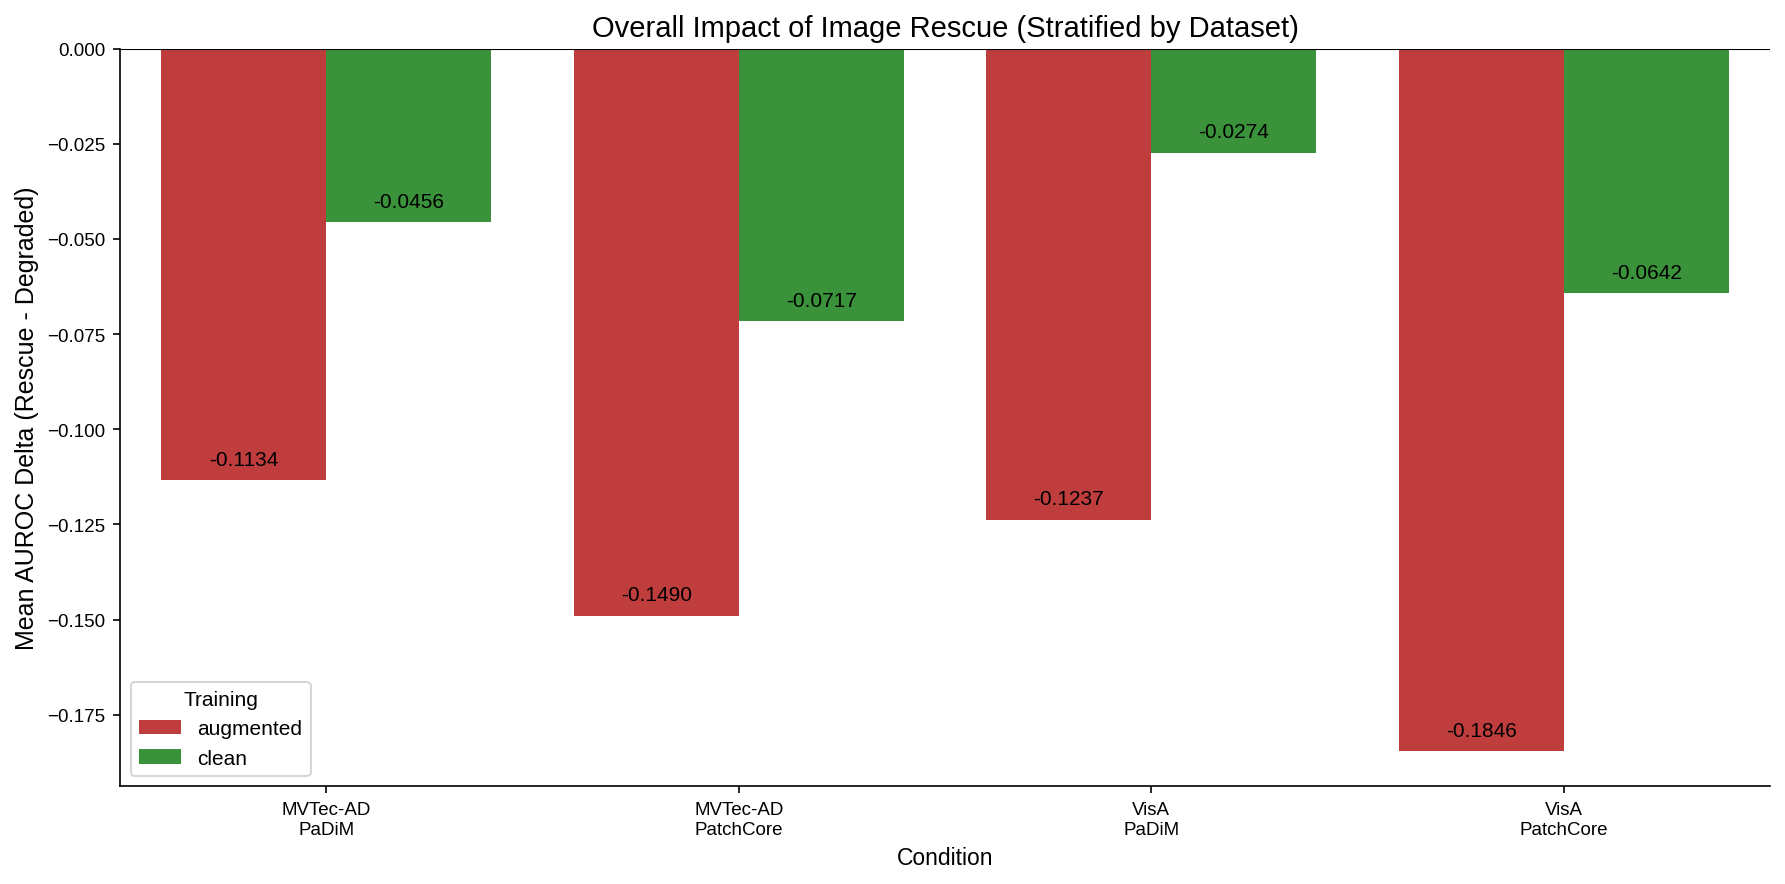

In [7]:
test2_df['Condition'] = test2_df['Dataset'] + '\n' + test2_df['Model']
fig, ax = plt.subplots(figsize=(12, 6))
import seaborn as sns
sns.barplot(data=test2_df, x='Condition', y='Mean Delta', hue='Training', palette=['#d62728', '#2ca02c'], ax=ax)
ax.set_title('Overall Impact of Image Rescue (Stratified by Dataset)', fontsize=14)
ax.set_ylabel('Mean AUROC Delta (Rescue - Degraded)', fontsize=12)
ax.axhline(0, color='black', linewidth=1)
for p in ax.patches:
    w = p.get_width()
    if w == 0:
        continue
    h = p.get_height()
    if pd.isna(h):
        continue
    ax.annotate(f"{h:+.4f}", (p.get_x() + w / 2., h),
                ha='center', va='center', xytext=(0, 10 if h < 0 else -15), textcoords='offset points')
sns.despine()
plt.tight_layout()
fig.savefig('08_wilcoxon_rescue_deltas.png', bbox_inches='tight')
plt.show()

---
## Test 3 — Per-Rescue-Method Wilcoxon Breakdown

Tests each rescue method individually per model & training condition.  
This provides statistical backing for claims like *"Wiener deconvolution is categorically harmful"* and *"CLAHE is the only conditionally beneficial rescue method"*.

In [8]:
print('=' * 60)
print('3. Wilcoxon Signed-Rank Test: Per-Rescue-Method Breakdown')
print('=' * 60)

test3_results = []

for (dataset, model, training, rescue_method), group in rescue_pairs.groupby(
        ['dataset', 'model', 'training', 'rescue_rescue']):
    if len(group) < 10:
        continue

    x = group['image_AUROC_deg']
    y = group['image_AUROC_rescue']

    stat_two, pval_two = wilcoxon(x, y, alternative='two-sided')
    stat_one, pval_one = wilcoxon(x, y, alternative='less')

    mean_diff = (y - x).mean()
    success_rate = (y > x).mean() * 100

    test3_results.append({
        'Dataset': dataset, 'Model': model, 'Training': training,
        'Rescue Method': rescue_method, 'N': len(group),
        'Mean Deg': x.mean(), 'Mean Res': y.mean(),
        'Mean Delta': mean_diff, 'Success %': success_rate,
        'p_two': pval_two, 'p_one': pval_one,
    })

test3_df = pd.DataFrame(test3_results)

# ── Apply Benjamini-Hochberg FDR correction across all 24 tests ──
_, pvals_fdr, _, _ = multipletests(test3_df['p_two'], method='fdr_bh')
test3_df['p_fdr'] = pvals_fdr
print(f"FDR correction applied. {(pvals_fdr < 0.05).sum()} / {len(pvals_fdr)} tests remain significant at q<0.05")

# Pretty-print per-method results
for (dataset, model, training), subdf in test3_df.groupby(['Dataset', 'Model', 'Training']):
    print(f'\n--- {dataset} - {model} ({training} training) ---')
    for _, row in subdf.sort_values('Mean Delta').iterrows():
        p = row['p_two']
        p_fdr = row['p_fdr']
        stars_raw = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        stars_fdr = '***' if p_fdr < 0.001 else ('**' if p_fdr < 0.01 else ('*' if p_fdr < 0.05 else 'n.s.'))
        print(f"  {row['Rescue Method']:25s}  N={row['N']:3d}  "
              f"delta={row['Mean Delta']:+.4f}  success={row['Success %']:5.1f}%  "
              f"p={p:.2e} {stars_raw}  p_fdr={p_fdr:.2e} {stars_fdr}")

3. Wilcoxon Signed-Rank Test: Per-Rescue-Method Breakdown
FDR correction applied. 36 / 48 tests remain significant at q<0.05

--- MVTec-AD - PaDiM (augmented training) ---
  Wiener                     N=135  delta=-0.2335  success=  5.9%  p=6.84e-23 ***  p_fdr=8.76e-22 ***
  Wiener (Motion PSF)        N=135  delta=-0.2119  success=  4.4%  p=7.30e-23 ***  p_fdr=8.76e-22 ***
  Retinex                    N=135  delta=-0.1080  success= 15.6%  p=1.10e-16 ***  p_fdr=8.83e-16 ***
  CLAHE                      N=135  delta=-0.0548  success= 25.2%  p=4.83e-12 ***  p_fdr=2.11e-11 ***
  NLM Denoise                N=135  delta=-0.0452  success= 30.4%  p=1.00e-06 ***  p_fdr=1.92e-06 ***
  Dehaze (Dark Channel)      N=135  delta=-0.0267  success= 34.8%  p=2.89e-04 ***  p_fdr=4.20e-04 ***

--- MVTec-AD - PaDiM (clean training) ---
  Wiener                     N=135  delta=-0.1411  success= 14.1%  p=3.38e-17 ***  p_fdr=3.24e-16 ***
  Wiener (Motion PSF)        N=135  delta=-0.0937  success= 22.2%  p=1.

### Figure 9 — Per-Method Significance Heatmap

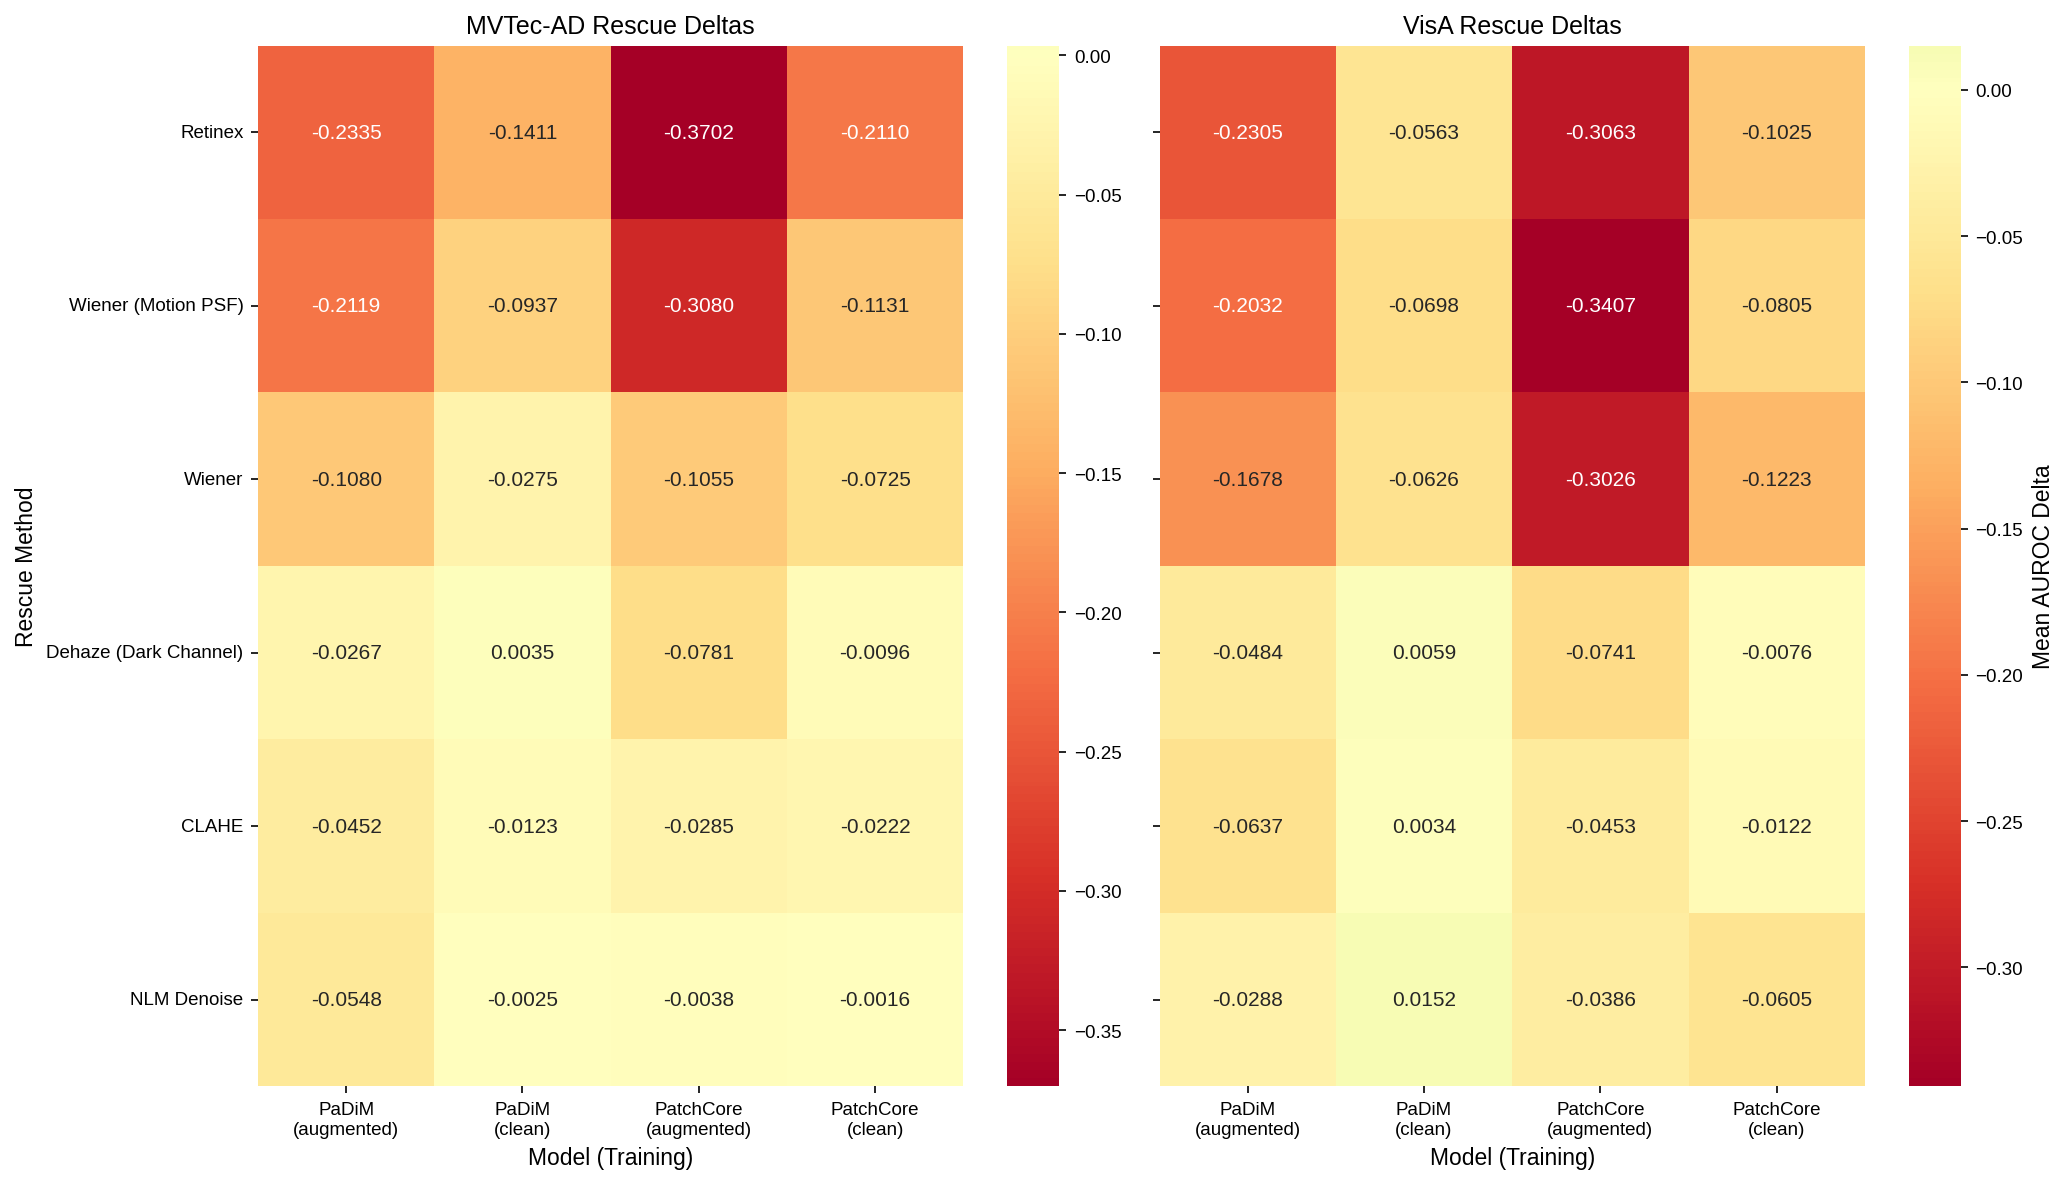

In [9]:
import seaborn as sns
datasets = test3_df['Dataset'].unique()
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 8), sharey=True)
if len(datasets) == 1:
    axes = [axes]
for i, ds in enumerate(datasets):
    ds_df = test3_df[test3_df['Dataset'] == ds].copy()
    ds_df['Condition'] = ds_df['Model'] + "\n(" + ds_df['Training'] + ")"
    pivot = ds_df.pivot_table(index='Rescue Method', columns='Condition', values='Mean Delta')
    pivot['mean'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('mean', ascending=True).drop('mean', axis=1)
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn", center=0, ax=axes[i], 
                cbar_kws={'label': 'Mean AUROC Delta'} if i == len(datasets)-1 else None)
    axes[i].set_title(f'{ds} Rescue Deltas')
    axes[i].set_xlabel('Model (Training)')
    if i == 0:
        axes[i].set_ylabel('Rescue Method')
    else:
        axes[i].set_ylabel('')
plt.tight_layout()
fig.savefig('09_wilcoxon_per_method_heatmap.png', bbox_inches='tight')
plt.show()

---
## Summary

| Test | What it measures | Key result |
|---|---|---|
| **Test 1** | Augmented vs Clean training under degradation | Augmented training significantly improves AUROC |
| **Test 2** | Overall rescue effect across all methods | Rescue is net-harmful in all 4 conditions |
| **Test 3** | Per-method rescue breakdown | Wiener is categorically harmful; CLAHE is the only conditionally neutral/positive method |

**Figures saved to `results/analysis/`:**
- `07_wilcoxon_augmentation_gains.png`
- `08_wilcoxon_rescue_deltas.png`
- `09_wilcoxon_per_method_heatmap.png`